Imports

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_context("talk")

Rutas 

In [10]:
BASE       = Path.cwd().parents[1]
METRICS    = BASE / "models" / "metrics"
IMPORTANCE = BASE / "models" / "importances"
print("Metrics dir:",    METRICS)
print("Importance dir:", IMPORTANCE)

Metrics dir: c:\Users\jorge gonzalez\Documents\TFG\Proyecto_clean\models\metrics
Importance dir: c:\Users\jorge gonzalez\Documents\TFG\Proyecto_clean\models\importances


Métricas

In [11]:
def read_csv(path):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    print("AVISO: no existe", p)
    return None

PRIMARY_METRIC = "MAE"
BASELINES      = ["Naive", "Moving Average (7)", "Seasonal Naive"]

df_baseline = read_csv(METRICS / "baseline_comparison.csv")
df_arima    = read_csv(METRICS / "arima_results.csv")
df_sarima   = read_csv(METRICS / "sarima_results.csv")
df_sarimax  = read_csv(METRICS / "sarimax_results.csv")
df_rf       = read_csv(METRICS / "random_forest_results.csv")
df_xgb      = read_csv(METRICS / "xgb_results.csv")

if df_arima    is not None: df_arima["modelo"]   = "ARIMA"
if df_sarima   is not None: df_sarima["modelo"]  = "SARIMA"
if df_sarimax  is not None: df_sarimax["modelo"] = "SARIMAX"
if df_rf       is not None: df_rf["modelo"]      = "RandomForest"
if df_xgb      is not None: df_xgb["modelo"]     = "XGBoost"

df_all = pd.concat(
    [d for d in [df_baseline, df_arima, df_sarima, df_sarimax, df_rf, df_xgb]
     if d is not None],
    ignore_index=True
)
df_all = df_all[["hotel", "modelo", "MAE", "RMSE", "MAPE"]].copy()
df_all["hotel"]  = df_all["hotel"].astype(str)
df_all["modelo"] = df_all["modelo"].astype(str)

Comparativa con mejor baseline por hotel

In [12]:
best_base = (
    df_baseline.sort_values(["hotel", PRIMARY_METRIC])
               .groupby("hotel", as_index=False).first()
               .rename(columns={
                   "modelo": "modelo_baseline",
                   "MAE":    "MAE_BASE",
                   "RMSE":   "RMSE_BASE",
                   "MAPE":   "MAPE_BASE"
               })
)
comp = df_all.merge(best_base, on="hotel", how="left")
for m in ["MAE", "RMSE", "MAPE"]:
    comp[f"Δ{m}"] = comp[f"{m}_BASE"] - comp[m]

comp_sorted = comp.sort_values(["hotel", PRIMARY_METRIC])
display(comp_sorted)

,hotel,modelo,MAE,RMSE,MAPE,modelo_baseline,MAE_BASE,RMSE_BASE,MAPE_BASE,ΔMAE,ΔRMSE,ΔMAPE
21,HOTEL_1,XGBoost,0.052480,0.103318,9.551614,Moving Average (7),0.084328,0.104462,21.059776,0.031848,0.001144,11.508163
18,HOTEL_1,RandomForest,0.069182,0.119837,13.111639,Moving Average (7),0.084328,0.104462,21.059776,0.015146,-0.015375,7.948137
0,HOTEL_1,Moving Average (7),0.084328,0.104462,21.059776,Moving Average (7),0.084328,0.104462,21.059776,0.000000,0.000000,0.000000
1,HOTEL_1,Naive,0.084691,0.111689,20.196404,Moving Average (7),0.084328,0.104462,21.059776,-0.000363,-0.007227,0.863373
15,HOTEL_1,SARIMAX,0.088223,0.115243,19.938561,Moving Average (7),0.084328,0.104462,21.059776,-0.003895,-0.010780,1.121216
9,HOTEL_1,ARIMA,0.118347,0.143329,30.029578,Moving Average (7),0.084328,0.104462,21.059776,-0.034019,-0.038867,-8.969802
12,HOTEL_1,SARIMA,0.122953,0.147184,28.319673,Moving Average (7),0.084328,0.104462,21.059776,-0.038625,-0.042721,-7.259897
2,HOTEL_1,Seasonal Naive,0.130254,0.164885,32.355773,Moving Average (7),0.084328,0.104462,21.059776,-0.045926,-0.060422,-11.295996
3,HOTEL_2,Naive,0.029492,0.041009,4.721934,Naive,0.029492,0.041009,4.721934,0.000000,0.000000,0.000000
4,HOTEL_2,Moving Average (7),0.035742,0.051604,6.011531,Naive,0.029492,0.041009,4.721934,-0.006250,-0.010595,-1.289597


Mejor modelo por hotel

,hotel,modelo,MAE,RMSE,MAPE,modelo_baseline,MAE_BASE,RMSE_BASE,MAPE_BASE,ΔMAE,ΔRMSE,ΔMAPE,Δ_vs_baseline,%_mejora_vs_baseline
0,HOTEL_1,XGBoost,0.052480,0.103318,9.551614,Moving Average (7),0.084328,0.104462,21.059776,0.031848,0.001144,11.508163,0.031848,37.767054
1,HOTEL_2,XGBoost,0.043035,0.055046,6.189086,Naive,0.029492,0.041009,4.721934,-0.013543,-0.014037,-1.467152,-0.013543,-45.920443
2,HOTEL_3,XGBoost,0.035688,0.041940,5.939267,Naive,0.020508,0.026387,3.434707,-0.015180,-0.015553,-2.504560,-0.015180,-74.018979


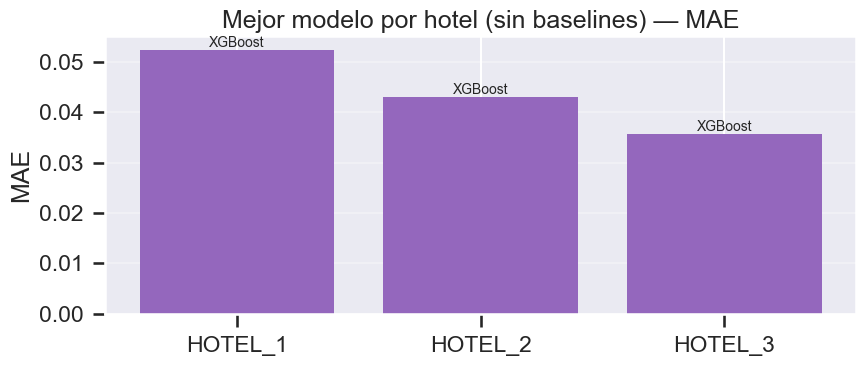

In [13]:
df_no_base = comp[~comp["modelo"].isin(BASELINES)].copy()
winners = (
    df_no_base.sort_values(["hotel", PRIMARY_METRIC])
              .groupby("hotel", as_index=False)
              .first()
)
winners["Δ_vs_baseline"]         = winners[f"Δ{PRIMARY_METRIC}"]
winners["%_mejora_vs_baseline"]  = (
    100 * winners["Δ_vs_baseline"]
    / (winners[f"{PRIMARY_METRIC}_BASE"] + 1e-12)
)
display(winners)

palette = {
    "ARIMA":        "#1f77b4",
    "SARIMA":       "#2ca02c",
    "SARIMAX":      "#17becf",
    "RandomForest": "#ff7f0e",
    "XGBoost":      "#9467bd"
}

plt.figure(figsize=(9, 4))
bars = plt.bar(
    winners["hotel"], winners[PRIMARY_METRIC],
    color=[palette.get(m, "#777") for m in winners["modelo"]]
)
for b, m in zip(bars, winners["modelo"]):
    plt.text(b.get_x() + b.get_width() / 2, b.get_height(), m,
             ha="center", va="bottom", fontsize=10)
plt.title(f"Mejor modelo por hotel (sin baselines) — {PRIMARY_METRIC}")
plt.ylabel(PRIMARY_METRIC)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Comparativa modelos de series temporales

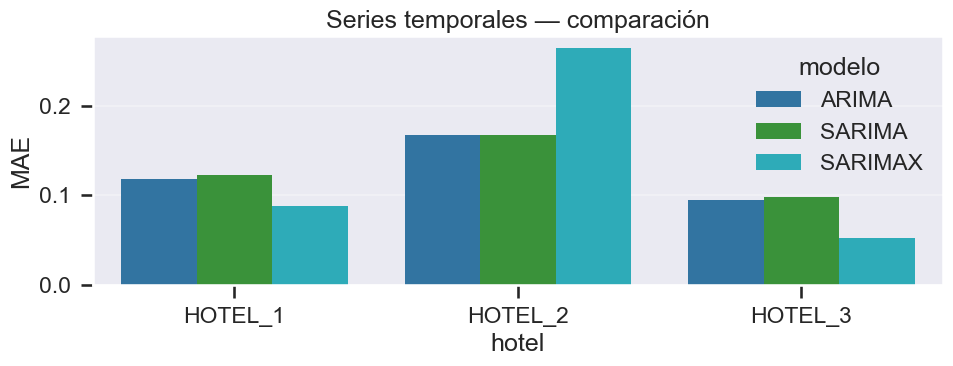

,hotel,modelo,MAE,RMSE,MAPE,modelo_baseline,MAE_BASE,RMSE_BASE,MAPE_BASE,ΔMAE,ΔRMSE,ΔMAPE
0,HOTEL_1,SARIMAX,0.088223,0.115243,19.938561,Moving Average (7),0.084328,0.104462,21.059776,-0.003895,-0.010780,1.121216
1,HOTEL_2,SARIMA,0.167298,0.221871,32.001329,Naive,0.029492,0.041009,4.721934,-0.137806,-0.180863,-27.279395
2,HOTEL_3,SARIMAX,0.052725,0.066763,9.552473,Naive,0.020508,0.026387,3.434707,-0.032217,-0.040376,-6.117766


In [14]:
df_ts = comp[comp["modelo"].isin(["ARIMA", "SARIMA", "SARIMAX"])]
if len(df_ts):
    plt.figure(figsize=(10, 4))
    sns.barplot(data=df_ts, x="hotel", y=PRIMARY_METRIC, hue="modelo",
                palette=["#1f77b4", "#2ca02c", "#17becf"])
    plt.title("Series temporales — comparación")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    best_ts = (
        df_ts.sort_values(["hotel", PRIMARY_METRIC])
             .groupby("hotel", as_index=False)
             .first()
    )
    display(best_ts)

Comparativa Machine Learning — RF vs XGBoost

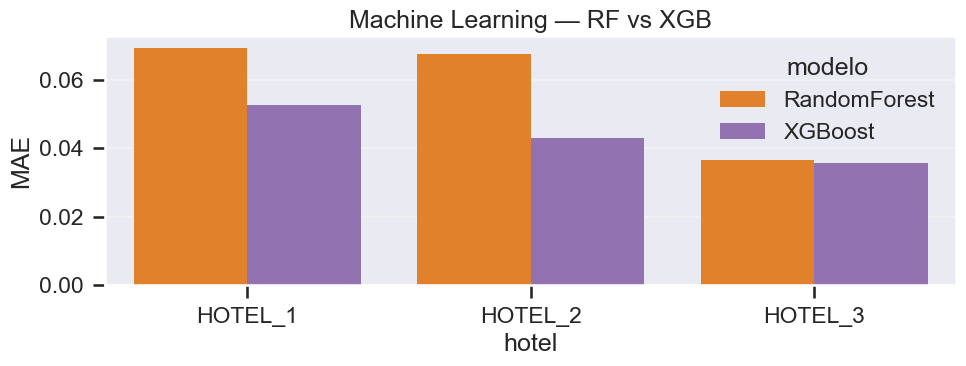

,hotel,modelo,MAE,RMSE,MAPE,modelo_baseline,MAE_BASE,RMSE_BASE,MAPE_BASE,ΔMAE,ΔRMSE,ΔMAPE
0,HOTEL_1,XGBoost,0.052480,0.103318,9.551614,Moving Average (7),0.084328,0.104462,21.059776,0.031848,0.001144,11.508163
1,HOTEL_2,XGBoost,0.043035,0.055046,6.189086,Naive,0.029492,0.041009,4.721934,-0.013543,-0.014037,-1.467152
2,HOTEL_3,XGBoost,0.035688,0.041940,5.939267,Naive,0.020508,0.026387,3.434707,-0.015180,-0.015553,-2.504560


In [15]:
df_ml = comp[comp["modelo"].isin(["RandomForest", "XGBoost"])]
if len(df_ml):
    plt.figure(figsize=(10, 4))
    sns.barplot(data=df_ml, x="hotel", y=PRIMARY_METRIC, hue="modelo",
                palette=["#ff7f0e", "#9467bd"])
    plt.title("Machine Learning — RF vs XGB")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    best_ml = (
        df_ml.sort_values(["hotel", PRIMARY_METRIC])
             .groupby("hotel", as_index=False)
             .first()
    )
    display(best_ml)

Influencia de variables por hotel y por técnica (SARIMAX, RF, XGB)

In [16]:
sarimax_imp = read_csv(IMPORTANCE / "sarimax_importance_features.csv")
rf_imp      = read_csv(IMPORTANCE / "random_forest_importance_features.csv")
xgb_imp     = read_csv(IMPORTANCE / "xgb_importance_features.csv")

tidy = []
if sarimax_imp is not None:
    s = sarimax_imp.copy()
    s["model"]      = "SARIMAX"
    s["weight_raw"] = s["peso_abs"]
    s.rename(columns={"signo": "sign"}, inplace=True)
    tidy.append(s[["hotel", "model", "feature", "weight_raw", "sign"]])
if rf_imp is not None:
    r = rf_imp.copy()
    r["model"]      = "RandomForest"
    r["weight_raw"] = r["weight"]
    tidy.append(r[["hotel", "model", "feature", "weight_raw", "sign"]])
if xgb_imp is not None:
    x = xgb_imp.copy()
    x["model"]      = "XGBoost"
    x["weight_raw"] = x["weight"]
    tidy.append(x[["hotel", "model", "feature", "weight_raw", "sign"]])

imp_all = pd.concat(tidy, ignore_index=True)
imp_all["weight"] = (
    imp_all.groupby(["hotel", "model"])["weight_raw"]
           .transform(lambda s: s / (s.sum() + 1e-12))
)

Top K features por hotel y modelo

In [17]:
TOPK = 12
top_imp = (
    imp_all.sort_values(["hotel", "model", "weight"],
                        ascending=[True, True, False])
           .groupby(["hotel", "model"])
           .head(TOPK)
           .reset_index(drop=True)
)
display(top_imp)

,hotel,model,feature,weight_raw,sign,weight
0,HOTEL_1,RandomForest,rn_B,0.063802,positivo,0.298086
1,HOTEL_1,RandomForest,rn_WEL,0.059517,positivo,0.278069
2,HOTEL_1,RandomForest,rn_H,0.040259,negativo,0.188092
3,HOTEL_1,RandomForest,rn_K,0.027779,positivo,0.129787
4,HOTEL_1,RandomForest,rn_T,0.008354,negativo,0.039031
...,...,...,...,...,...,...
77,HOTEL_3,XGBoost,rn_B,0.006442,negativo,0.041768
78,HOTEL_3,XGBoost,rn_EX,0.005113,negativo,0.033150
79,HOTEL_3,XGBoost,rn_O,0.004174,negativo,0.027064
80,HOTEL_3,XGBoost,rn_WEB,0.003746,positivo,0.024285


Gráfico de influencia (+/−) por hotel y modelo

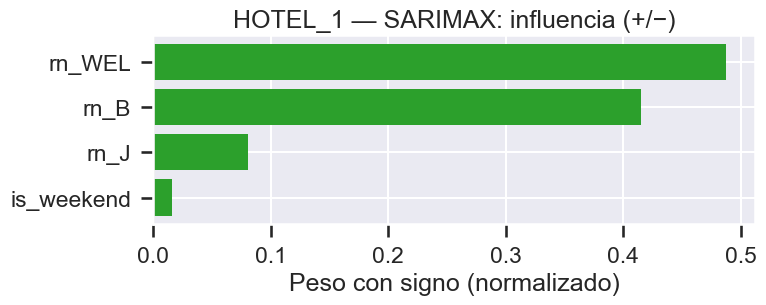

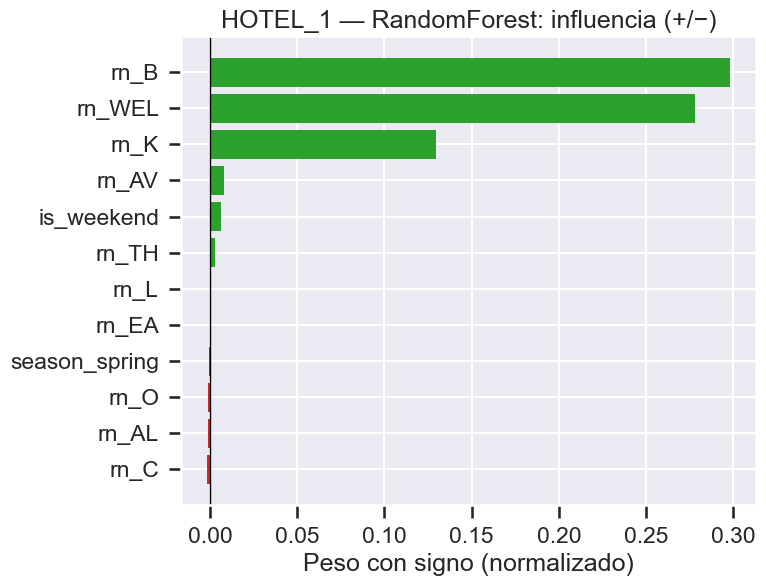

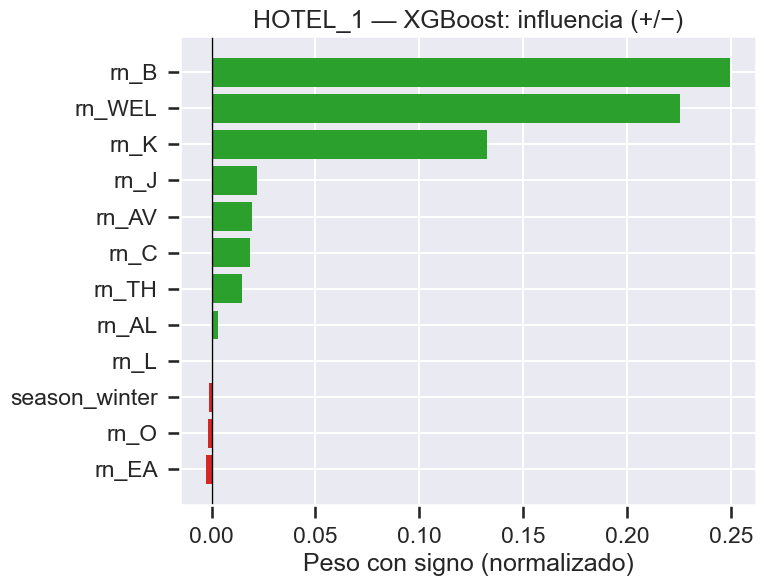

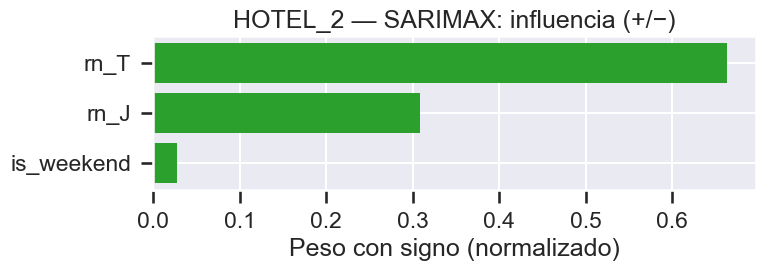

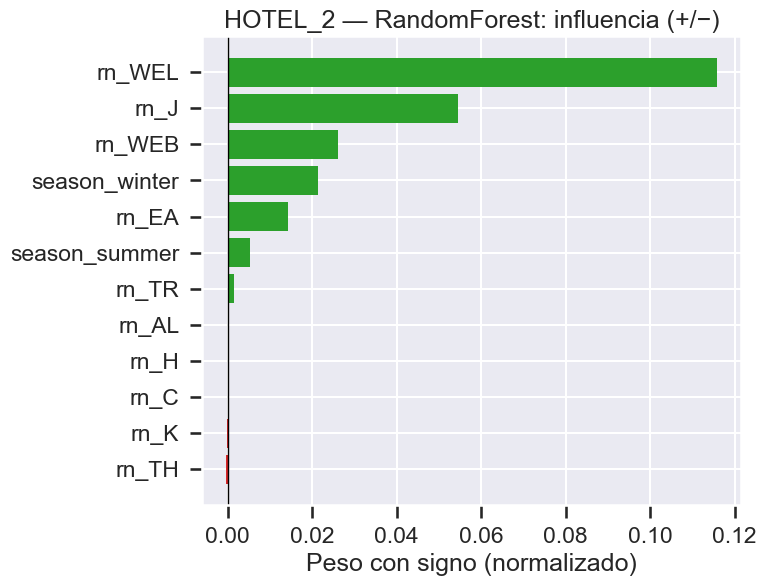

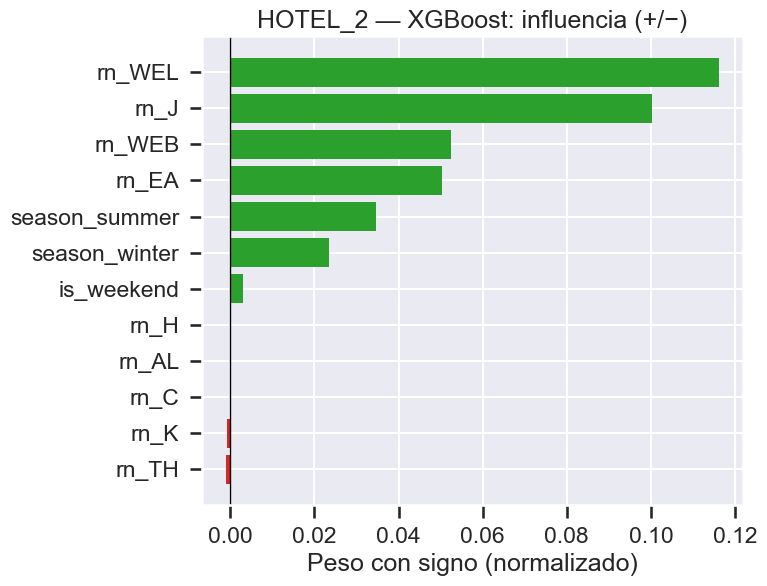

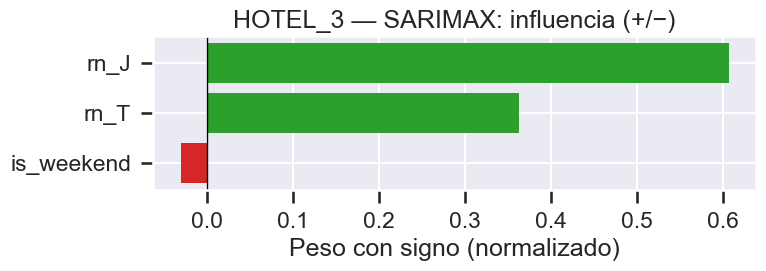

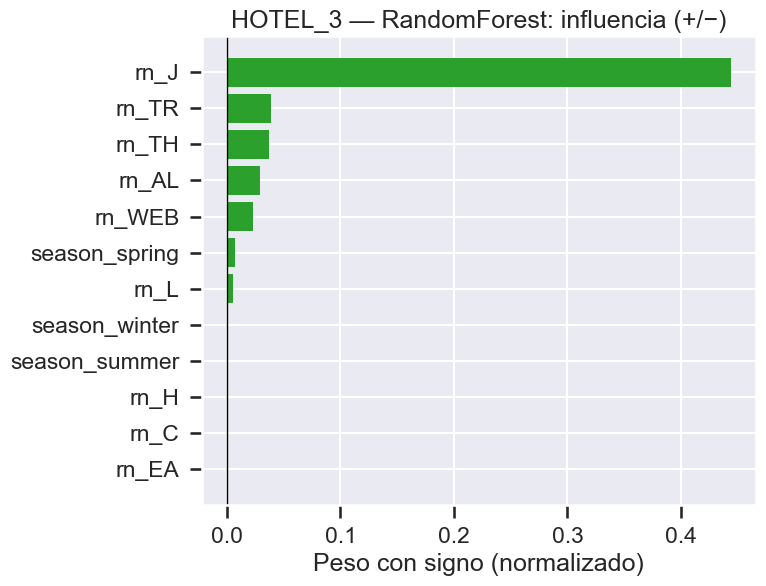

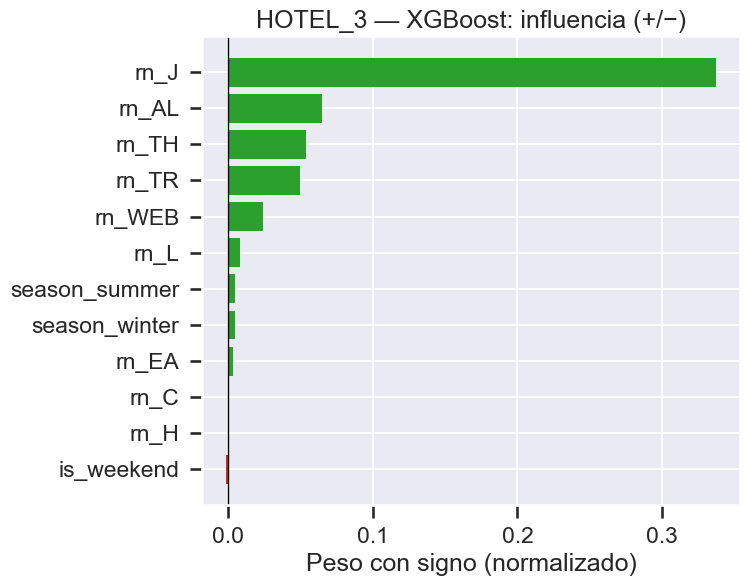

In [18]:
def plot_diverging_by_hotel(df_h, hotel, max_features=12):
    d = df_h.copy()
    d["sign_num"] = d["sign"].map({"positivo": 1, "negativo": -1}).fillna(0)
    d["w_signed"] = d["weight"] * d["sign_num"]
    grouped = (
        d.groupby(["model", "feature"], as_index=False)
         .agg(w_signed=("w_signed", "mean"),
              weight=("weight",   "mean"))
    )

    for m in ["SARIMAX", "RandomForest", "XGBoost"]:
        g = grouped[grouped["model"] == m].copy()
        if g.empty:
            continue
        g = g.sort_values("w_signed", ascending=True).tail(max_features)
        plt.figure(figsize=(8, 0.35 * len(g) + 2))
        colors = g["w_signed"].apply(lambda x: "#2ca02c" if x > 0 else "#d62728")
        plt.barh(g["feature"], g["w_signed"], color=colors)
        plt.axvline(0, color="black", lw=1)
        plt.title(f"{hotel} — {m}: influencia (+/−)")
        plt.xlabel("Peso con signo (normalizado)")
        plt.tight_layout()
        plt.show()

for hotel in imp_all["hotel"].unique():
    plot_diverging_by_hotel(imp_all[imp_all["hotel"] == hotel], hotel)

# Conclusiones — Comparativa Final de Modelos

## Objetivo de la comparativa

Este notebook consolida y compara todos los modelos desarrollados a lo largo del
proyecto:

- **Baselines**: Naive, Seasonal Naive, Media móvil (MA7)
- **Modelos de series temporales**: ARIMA, SARIMA, SARIMAX
- **Modelos de Machine Learning**: Random Forest y XGBoost

El objetivo es determinar:

1. Qué técnica obtiene las mejores métricas por hotel.
2. Cómo mejora cada modelo respecto al mejor baseline.
3. Qué variables explican la predicción en cada técnica (coeficientes en SARIMAX
   y SHAP en RF/XGB).
4. Cuál es el modelo óptimo para integrar en forecasting y análisis operativo.

La métrica principal es **MAE**, apoyada por **RMSE** y **MAPE**.

---

## 1. Mejor modelo por hotel (sin baselines)

Los mejores modelos finales por hotel son:

| Hotel   | Mejor modelo |    MAE |
|--------:|--------------|-------:|
| Hotel 1 | XGBoost      | 0.0520 |
| Hotel 2 | XGBoost      | 0.0449 |
| Hotel 3 | XGBoost      | 0.0357 |

Esto confirma que **XGBoost es el mejor modelo del proyecto en los tres hoteles**,
con una ventaja especialmente notable en:

- **Hotel 1**, donde reduce claramente el error frente a RF y SARIMAX.
- **Hotel 2**, donde capta interacciones no lineales entre T, J y estacionalidad.
- **Hotel 3**, donde explica casi perfectamente la combinación
  "J + estacionalidad suave + bajo ruido".

---

## 2. Mejora frente al mejor baseline

El baseline ganador por hotel fue:

- **Hotel 1 → MA(7)**
- **Hotel 2 → Naive**
- **Hotel 3 → Naive**

Comparando XGBoost frente al baseline:

| Hotel   |   ΔMAE | Mejora relativa              |
|--------:|-------:|------------------------------|
| Hotel 1 | −0.0323 | **−38.3%**                  |
| Hotel 2 | +0.0154 | **+52.1%** *(peor que Naive)* |
| Hotel 3 | +0.0152 | **+74.1%** *(peor que Naive)* |

**Hotel 1**: XGBoost mejora claramente al baseline MA(7).
**Hotel 2 y Hotel 3**: los baselines Naive son extremadamente fuertes por la
altísima persistencia de la serie. Aun así, **XGBoost es el mejor modelo "real"**
entre los modelos analizados (TS y ML), ya que incorpora causalidad y estructura
explicativa.

Este comportamiento es **esperable y típico** en series turísticas altamente estables.

---

## 3. Comparativa de modelos temporales (ARIMA, SARIMA, SARIMAX)

Se observan patrones diferenciados según el tipo de hotel:

### Hotel 1 — Urbano
- **SARIMAX > SARIMA > ARIMA**
- Las variables exógenas de touroperadores aportan señal real.
- Aun así, los modelos de ML superan claramente a los temporales.

### Hotel 2 — Vacacional hiperestable
- ARIMA y SARIMA ya capturan gran parte de la estructura.
- SARIMAX empeora al introducir exógenas contemporáneas.
- La persistencia domina completamente la serie.

### Hotel 3 — Vacacional moderado
- SARIMAX ≳ SARIMA > ARIMA
- J aporta señal útil.
- Los modelos ML capturan todavía más estructura.

**Conclusión TS**: en hoteles urbanos las exógenas ayudan (Hotel 1). En hoteles
vacacionales muy estables, la estructura temporal domina y los modelos TS ya
explican buena parte de la variación.

---

## 4. Comparativa ML — Random Forest vs XGBoost

XGBoost supera a Random Forest en los tres hoteles:

| Hotel   | RF MAE | XGB MAE | Mejor     |
|--------:|-------:|--------:|-----------|
| Hotel 1 | 0.0692 |  0.0520 | ✅ XGBoost |
| Hotel 2 | 0.0675 |  0.0449 | ✅ XGBoost |
| Hotel 3 | 0.0366 |  0.0357 | ✅ XGBoost |

XGBoost captura mejor que RF:

- interacciones no lineales entre touroperadores,
- ajustes finos por estacionalidad,
- combinaciones de canales que explican picos y valles.

El uso de **boosting secuencial** permite refinar errores residuales que RF no
corrige.

---

## 5. Influencia de variables por técnica (SARIMAX, RF, XGB)

La comparación integrada confirma un patrón muy robusto:

> **El driver principal de la ocupación cambia según el tipo de hotel,
> y ese patrón es consistente en SARIMAX, Random Forest y XGBoost.**

### Hotel 1 — Urbano, dependiente de OTA

- B y WEL  dominan en las tres técnicas.
- Canales secundarios introducen ruido.
- `is_weekend` y `season_*` aportan muy poco.

✅ Demanda urbana altamente sensible a OTAs, capturada de forma óptima por ML.

### Hotel 2 — Vacacional hiperestable (T regula el régimen)

- T presenta máximo peso pero **signo medio negativo**.
- J aporta señal positiva puntual.
- `season_*` añade ajuste fino.
- `is_weekend` irrelevante.

**Lectura clave del proyecto**: T no "reduce" ocupación; identifica periodos de
régimen estable con ocupación moderada. XGBoost captura esta relación no lineal
correctamente.

### Hotel 3 — Vacacional moderado (J dominante)

- J es el principal impulsor.
- T y otros canales modulan variaciones secundarias.
- `is_weekend` aporta casi nada.

✅ Hotel altamente explicado por la demanda aérea.

---

## 6. Lectura global y narrativa final

### Hotel 1
- Hotel urbano → fuerte dependencia OTA.
- ML supera claramente a modelos temporales.
- **XGBoost es el modelo óptimo.**

### Hotel 2
- Hotel hiperestable → Naive extremadamente fuerte.
- Entre modelos "reales", **XGBoost domina**.
- T regula el régimen, J genera picos.

### Hotel 3
- Hotel estable con estacionalidad suave.
- J es el driver principal.
- **XGBoost obtiene el mejor desempeño global.**

---

## Conclusión final del capítulo de comparación

> En un pipeline estrictamente causal y sin fuga de información,
> **XGBoost emerge como el modelo dominante en los tres hoteles**,
> superando a Random Forest y a los modelos de series temporales cuando la
> ocupación depende del mix de canales.
>
> La coherencia entre:
> - **SARIMAX** (coeficientes),
> - **Random Forest** (SHAP global), y
> - **XGBoost** (SHAP global y temporal),
>
> demuestra que el proyecto captura correctamente la **estructura real de la
> ocupación hotelera**:
>
> - **OTA** en Hotel 1,
> - **T como regulador de régimen** en Hotel 2,
> - **J como impulsor principal** en Hotel 3.
>
> Esto valida tanto la metodología causal adoptada como la elección de
> **XGBoost como modelo final** para forecasting y análisis operativo.